In [1]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import scipy.stats as stats

In [3]:
import scipy.signal as signal
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
import pymannkendall as mk


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [ ]:
yearb=1941
yeare=2025

ifile='ERA5_AFI_1941_2025_updated.nc'

dso = xr.open_dataset(ifile)
dso = dso.sortby('lat')
units = dso['AFI'].units
dso['time']=np.arange(yearb,yeare+1,1)


In [ ]:
fileGLOST = 'annual_LOESS_NOAA_GLOST_anomaly.nc'
ds_glost=xr.open_dataset(fileGLOST)
ann_glost = ds_glost['glost']
dso=dso.merge({'glost':ann_glost})

In [12]:
lon_min = 190
lon_max = 310 
lat_min =  19
lat_max =  75 
ds = dso.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon = ds.lon.data
Tlat = ds.lat.data

# Compute Durbin-Watson & Augmented Dickey-Fuller (ADF)  test 

In [13]:
dw = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
adf = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
mkp = xr.zeros_like(ds['AFI'].mean('time'))*np.nan
mkt = xr.zeros_like(ds['AFI'].mean('time'))*np.nan

mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)

# 1. Prepare your data (Example: y depends on x)
x = ds['glost'].data

for ij in range(0,len(idlon)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]

  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat)


  y = dsij['AFI'].data
  if any(y)>0:
    # 2. Fit a regression model
    x = sm.add_constant(x) # Add an intercept
    model = sm.OLS(y, x).fit()

    # 3. Perform Durbin-Watson test on the residuals
    dw_statistic = durbin_watson(model.resid)
    result_adf = adfuller(y)
    result_mk = mk.original_test(y)

    dw.loc[{'lat':ilat,'lon':ilon}] = dw_statistic
    adf.loc[{'lat':ilat,'lon':ilon}] = result_adf[1]
    mkp.loc[{'lat':ilat,'lon':ilon}] = result_mk.p
    mkt.loc[{'lat':ilat,'lon':ilon}] = result_mk.Tau

Text(0.5, 1.0, 'Durbin-Watson statistic')

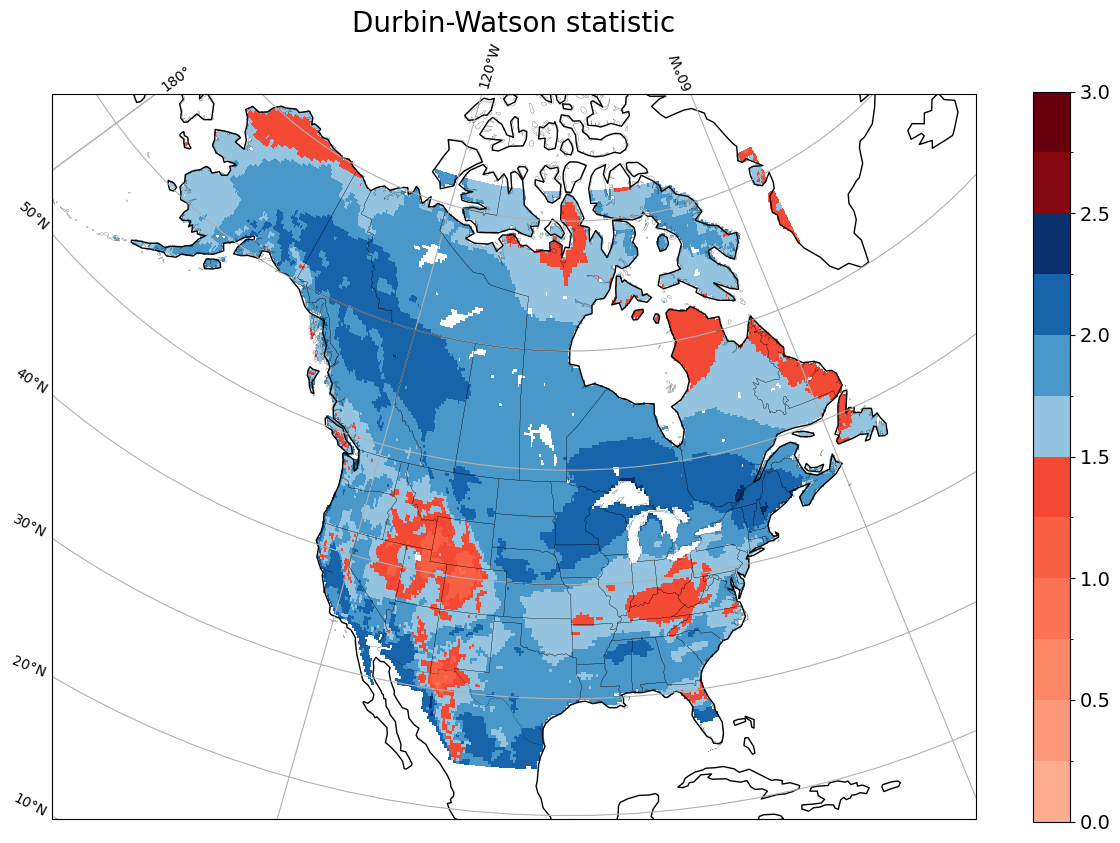

In [14]:
from matplotlib import colors
clevs = np.arange(0,3.25,0.25)
cmap_r=plt.get_cmap('Reds',len(clevs)+5)
cmap_b=plt.get_cmap('Blues',4+2)
ccolors = [cmap_r(i) for i in range(5,cmap_r.N)]
ccolors[np.where(clevs==1.5)[0].item():np.where(clevs==2.5)[0].item()+1]=[cmap_b(i) for i in range(2,cmap_b.N)]
cmap= colors.LinearSegmentedColormap.from_list('Custom cmap',\
                ccolors, len(ccolors))
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=dw.plot.pcolormesh(ax=ax,cmap=cmap,levels=clevs,transform=ccrs.PlateCarree(),\
                        add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Durbin-Watson statistic',fontsize=20)

The Durbin-Watson statistic is a test for autocorrelation in the residuals of a regression analysis onto the GLOST. The Durbin-Watson statistic will always have a value ranging between 0 and 4. A value of 2.0 indicates there is no autocorrelation detected in the sample. Values from 0 to less than 2 point to positive autocorrelation, and values from 2 to 4 mean negative autocorrelation. Typically, the Durbin-Watson statistic values that are in the range of 1.5 to 2.5 are considered normal.

In [16]:
## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

Text(0.5, 1.0, 'ADF pvalue')

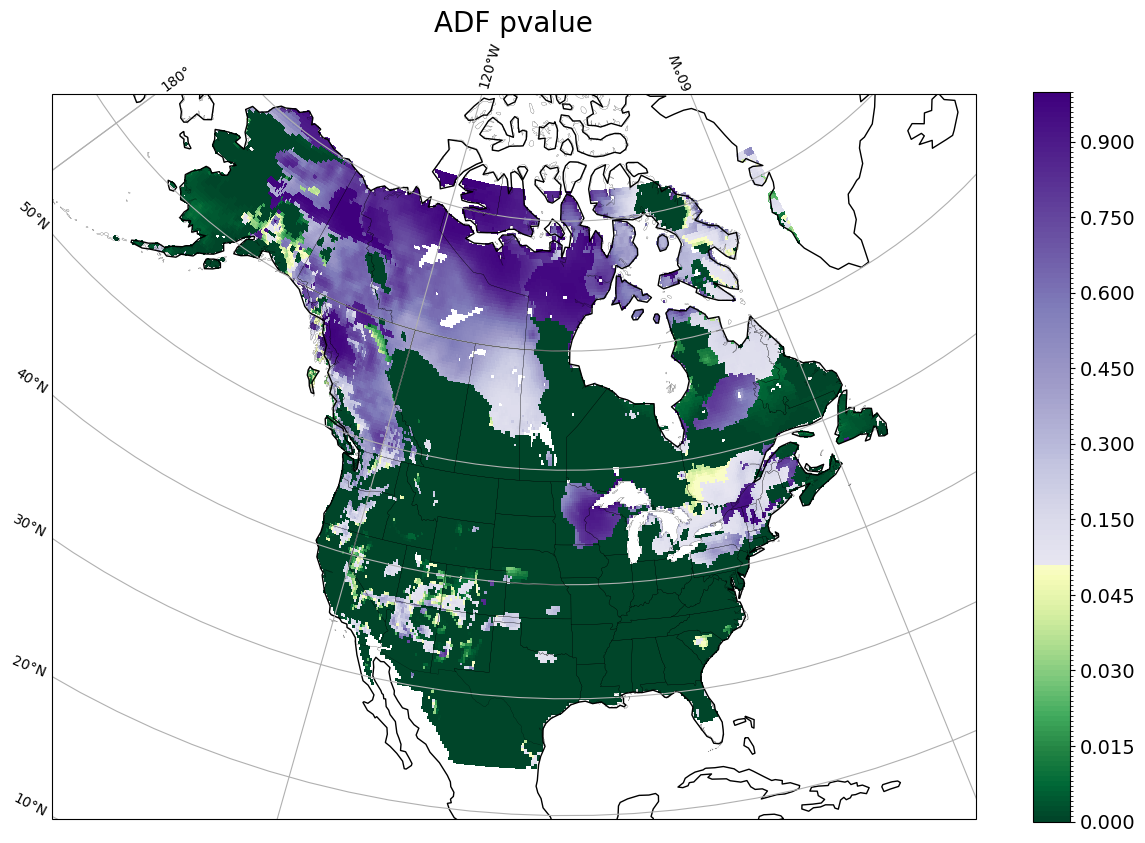

In [17]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=adf.plot.pcolormesh(ax=ax,cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'ADF pvalue',fontsize=20)

Interpretation: <br>
Null Hypothesis (\(H_{0}\)): The series has a unit root and is non-stationary.<br>
Alternative Hypothesis (\(H_{1}\)): The series is stationary.<br>
To make a decision, look at the p-value or compare the ADF Statistic to the critical values:Stationary <br>
**pvalue <= 0.05**: Reject \(H_{0}\). The data does not have a unit root and is stationary.Non-Stationary <br>
**pvalue > 0.05**: Fail to reject \(H_{0}\). The data has a unit root and is non-stationary.<br>
Statistical Strength: A more negative ADF Statistic indicates stronger evidence against the null hypothesis<br>

Text(0.5, 1.0, 'Mann-Kendall Trend Test pvalue')

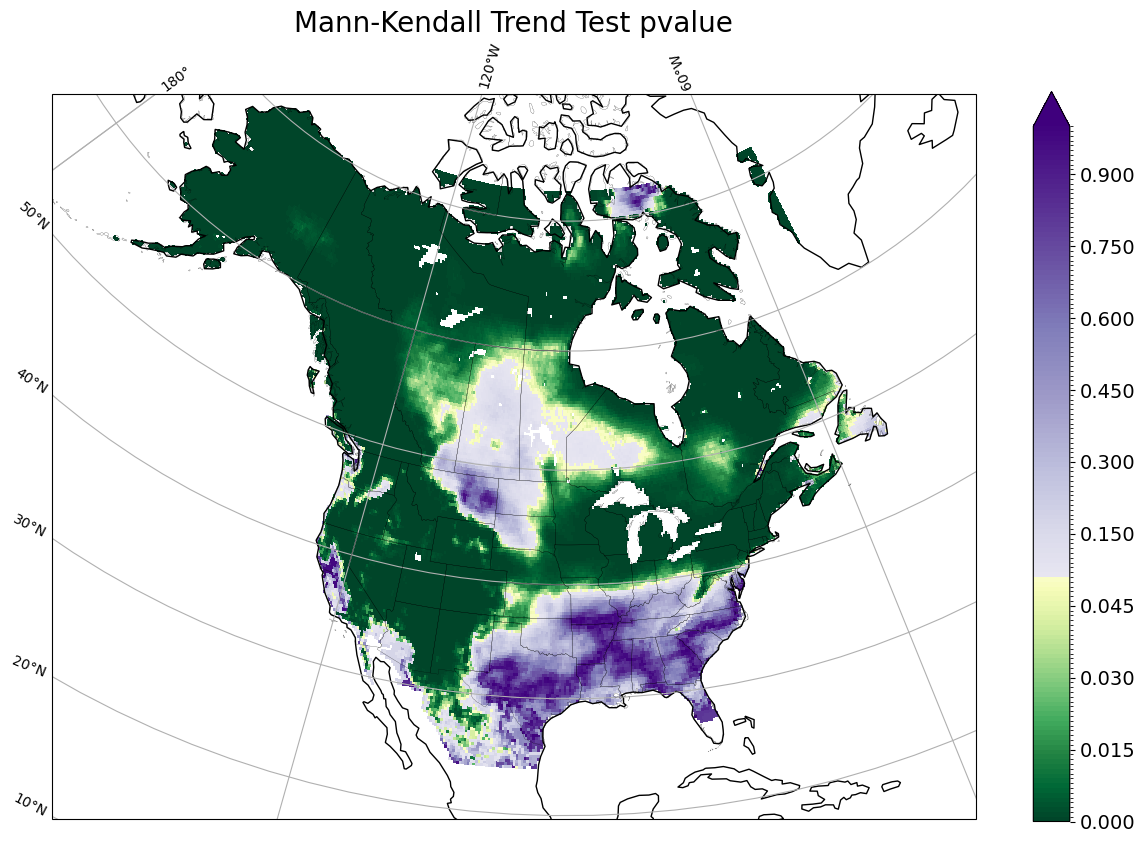

In [18]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=mkp.plot.pcolormesh(ax=ax,cmap=pvalue_cmap,levels=clevs_pv,transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Mann-Kendall Trend Test pvalue',fontsize=20)

The Mann-Kendall (MK) test detects monotonic upward or downward trends in time-series data without assuming normality. It uses a statistic, \(S\), where positive values indicate an increasing trend and negative values indicate a decreasing trend. Significance is determined by the p-value (often <0.05) and Kendall’s Tau (\(\tau \))

Text(0.5, 1.0, 'Mann-Kendall Trend Test Tau')

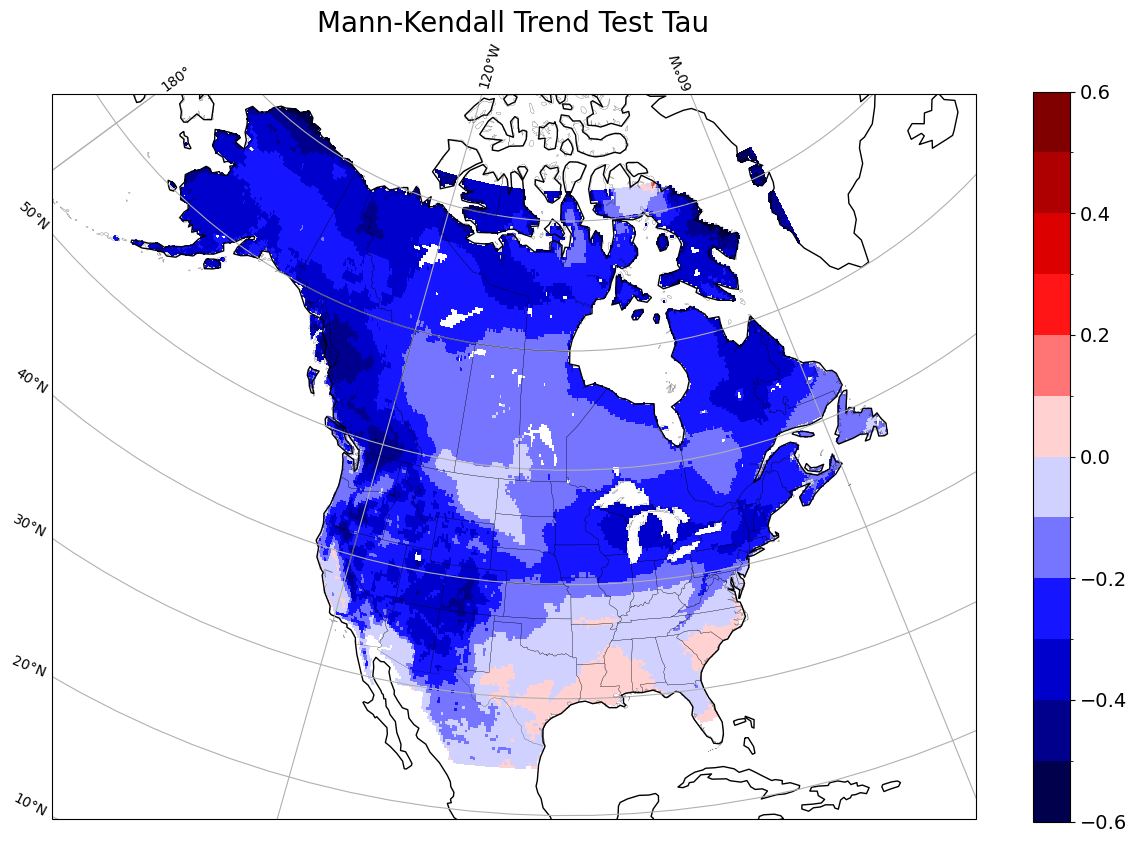

In [19]:
proj=ccrs.LambertConformal(265,25)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.95)

clevs = np.arange(0,3.25,0.25)
cc=mkt.plot.pcolormesh(ax=ax,cmap='seismic',levels=np.arange(-0.6,0.7,0.1),transform=ccrs.PlateCarree(), add_colorbar=False)
ax.set_extent([-140+360, -60, 15, 75], ccrs.Geodetic())
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
ax.coastlines()
cbar=fig.colorbar(cc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)  
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels
plt.title(f'Mann-Kendall Trend Test Tau',fontsize=20)